<a href="https://colab.research.google.com/github/Swathi04705/Applied-Machine-Learning-Lab/blob/main/salary_income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# salary dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("drive/My Drive/Colab Notebooks/datasets/Salary_Data.csv")
dataset = data
data

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


# Simple Linear Regression on Salary Data

In [ ]:
X_salary = dataset[['YearsExperience']]
y_salary = dataset['Salary']

print("Features (X_salary) head:")
display(X_salary.head())
print("\nTarget (y_salary) head:")
display(y_salary.head())

Features (X_salary) head:


,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2



Target (y_salary) head:


,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_salary,
    y_salary,
    test_size = 0.2,
    random_state = 42
)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [ ]:
# Create and train the Linear Regression model on the training data
model_salary = LinearRegression()
model_salary.fit(X_train, y_train)

# Make predictions on the test data
y_pred_salary = model_salary.predict(X_test)

print("Model Intercept:", model_salary.intercept_)
print("Model Coefficient (Slope):", model_salary.coef_[0])

Model Intercept: 25321.583011776813
Model Coefficient (Slope): 9423.815323030976


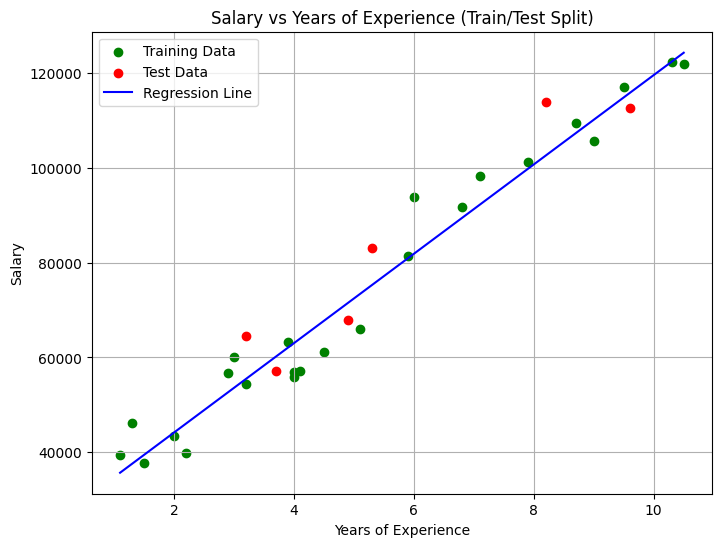

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Training data points
plt.scatter(X_train, y_train, color='green', label='Training Data')

# Test data points
plt.scatter(X_test, y_test, color='red', label='Test Data')

# Regression line (using the full range of X for the line)
plt.plot(X_salary, model_salary.predict(X_salary),
         color='blue', label='Regression Line') # Changed regression line to blue for contrast

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Years of Experience (Train/Test Split)')
plt.legend()
plt.grid(True)
plt.show()

Update the code with feature scaling and write your comments.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


In [ ]:
#predict salary for a person with 7.5 years of experience
predicted_salary = model_salary.predict([[7.5]])
print(f"Predicted Salary for 7.5 years of experience: ${predicted_salary[0]:.2f}")

Predicted Salary for 7.5 years of experience: $96000.20


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Ridge linear regression

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


#create a pipeline:
#1. Standardize the predictors
#2. Apply ridge regression
model = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))



MAE: 6276.678088721407
MSE: 49948555.96597085
RMSE: 7067.429233177425
R2: 0.9022142665903492


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
model.fit(X_train, y_train)
ridge_model = model.named_steps['ridgecv']
print(f"Best alpha: {ridge_model.alpha_}")


Best alpha: 0.1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

# Re-loading and splitting salary data to ensure correct context
salary_data = pd.read_csv("drive/My Drive/Colab Notebooks/datasets/Salary_Data.csv")
X_salary_full = salary_data[['YearsExperience']]
y_salary_full = salary_data['Salary']
X_train_salary, X_test_salary, y_train_salary, y_test_salary = train_test_split(
    X_salary_full,
    y_salary_full,
    test_size = 0.2,
    random_state = 42
)

# Re-create and fit the salary RidgeCV pipeline
salary_ridge_pipeline = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
salary_ridge_pipeline.fit(X_train_salary, y_train_salary)
salary_ridge_estimator = salary_ridge_pipeline.named_steps['ridgecv']

print(f"Salary Ridge Model Coefficients: {salary_ridge_estimator.coef_}")
print(f"Salary Ridge Model Intercept: {salary_ridge_estimator.intercept_}")

Salary Ridge Model Coefficients: [27038.87544481]
Salary Ridge Model Intercept: 74207.625


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

#two predictors
X = np.array([[1, 8], [2, 13], [3, 22], [4, 27], [5, 36]])
y = np.array([40, 48, 57, 65, 74])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#create ridge model
ridge_model = Ridge(alpha=1.0)

#train the model
model = ridge_model.fit(X_scaled, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56.8
Coefficients: [5.55206191 5.38452196]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

#two predictors
X = np.array([[1, 8], [2, 13], [3, 22], [4, 27], [5, 36]])
y = np.array([40, 48, 57, 65, 74])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#create ridge model
ridge_model = Ridge(alpha=10.0) #whichever is giving small coefiicient value

#train the model
model = ridge_model.fit(X_scaled, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56.8
Coefficients: [3.01312559 2.9960059 ]


# INCOME DATASET

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv("drive/My Drive/Colab Notebooks/datasets/income_data.csv")
dataset = data
data

,Unnamed: 0,income,happiness
0,1,3.862647,2.314489
1,2,4.979381,3.433490
2,3,4.923957,4.599373
3,4,3.214372,2.791114
4,5,7.196409,5.596398
...,...,...,...
493,494,5.249209,4.568705
494,495,3.471799,2.535002
495,496,6.087610,4.397451
496,497,3.440847,2.070664


In [ ]:
income_data = pd.read_csv("drive/My Drive/Colab Notebooks/datasets/income_data.csv")
X_income_full = income_data[['income']]
y_happiness_full = income_data['happiness']
X_train_income, X_test_income, y_train_income, y_test_income = train_test_split(
    X_income_full,
    y_happiness_full,
    test_size=0.2,
    random_state=42
)

In [ ]:
model_income = LinearRegression()
model_income.fit(X_train_income, y_train_income)

y_pred = model_income.predict(X_test_income)

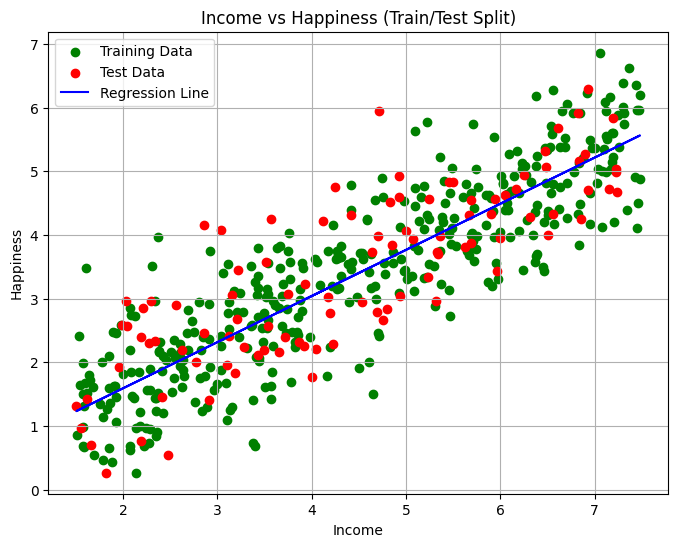

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Training data points
plt.scatter(X_train_income, y_train_income, color='green', label='Training Data')

# Test data points
plt.scatter(X_test_income, y_test_income, color='red', label='Test Data')

# Regression line (using the full range of X for the line)
plt.plot(X_income_full, model_income.predict(X_income_full),
         color='blue', label='Regression Line') # Changed regression line to blue for contrast

plt.xlabel('Income')
plt.ylabel('Happiness')
plt.title('Income vs Happiness (Train/Test Split)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


#create a pipeline:
#1. Standardize the predictors
#2. Apply ridge regression
model = make_pipeline(StandardScaler(), Ridge(alpha=0.1))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))



MAE: 6276.678088721407
MSE: 49948555.96597085
RMSE: 7067.429233177425
R2: 0.9022142665903492


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
model.fit(X_train, y_train)
ridge_model = model.named_steps['ridgecv']
print(f"Best alpha: {ridge_model.alpha_}")


Best alpha: 0.1


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

# Re-loading and splitting income data to ensure correct context


# Re-create and fit the income RidgeCV pipeline
income_ridge_pipeline = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
income_ridge_pipeline.fit(X_train_income, y_train_income)
income_ridge_estimator = income_ridge_pipeline.named_steps['ridgecv']

print(f"Income Ridge Model Coefficients: {income_ridge_estimator.coef_}")
print(f"Income Ridge Model Intercept: {income_ridge_estimator.intercept_}")

Income Ridge Model Coefficients: [1.27410613]
Income Ridge Model Intercept: 3.3881444001909546


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

#two predictors
X = np.array([[1, 8], [2, 13], [3, 22], [4, 27], [5, 36]])
y = np.array([40, 48, 57, 65, 74])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#create ridge model
ridge_model = Ridge(alpha=1.0)

#train the model
model = ridge_model.fit(X_scaled, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56.8
Coefficients: [5.55206191 5.38452196]


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

#two predictors
X = np.array([[1, 8], [2, 13], [3, 22], [4, 27], [5, 36]])
y = np.array([40, 48, 57, 65, 74])

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#create ridge model
ridge_model = Ridge(alpha=10.0)

#train the model
model = ridge_model.fit(X_scaled, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 56.8
Coefficients: [3.01312559 2.9960059 ]


Question-1:

Create a dataset containing temperature and electricity consumption.
Train a simple linear regression model.
Divide the data into training and testing sets.
Print the slope and intercept.
Calculate MAE, MSE, RMSE, and (R^2).
Plot the regression line.
Plot residuals.
Add another input feature and train a multiple regression model.
Compare simple and multiple regression performance.
Investigate the effect of adding an outlier.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_samples = 100
temperature = np.random.uniform(5, 35, num_samples) # Temperature in Celsius
# Electricity consumption is positively correlated with temperature, with some noise
electricity_consumption = 50 + 2 * temperature + np.random.normal(0, 10, num_samples)

data_simple = pd.DataFrame({'Temperature': temperature, 'Electricity_Consumption': electricity_consumption})

display(data_simple.head())
display(data_simple.describe())

,Temperature,Electricity_Consumption
0,16.236204,83.342878
1,33.521429,114.052785
2,26.959818,104.837244
3,22.959755,76.043820
4,9.680559,67.164400


,Temperature,Electricity_Consumption
count,100.000000,100.000000
mean,19.105422,88.200041
std,8.924682,18.791379
min,5.165664,52.380621
25%,10.796023,73.027944
50%,18.924274,86.760558
75%,26.906094,102.976384
max,34.606608,130.443951


In [ ]:
# Define features (X) and target (y)
X_simple = data_simple[['Temperature']]
y_simple = data_simple['Electricity_Consumption']

# Divide the data into training and testing sets
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.3, random_state=42
)

# Train a simple linear regression model
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)

# Print the slope and intercept
print(f"Simple Linear Regression Model:")
print(f"  Intercept: {model_simple.intercept_:.2f}")
print(f"  Slope (Coefficient for Temperature): {model_simple.coef_[0]:.2f}")

# Make predictions on the test set
y_pred_simple = model_simple.predict(X_test_simple)

# Calculate MAE, MSE, RMSE, and R^2
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print(f"\nPerformance Metrics (Simple Linear Regression):")
print(f"  MAE: {mae_simple:.2f}")
print(f"  MSE: {mse_simple:.2f}")
print(f"  RMSE: {rmse_simple:.2f}")
print(f"  R^2: {r2_simple:.2f}")

Simple Linear Regression Model:
  Intercept: 51.96
  Slope (Coefficient for Temperature): 1.84

Performance Metrics (Simple Linear Regression):
  MAE: 5.97
  MSE: 63.09
  RMSE: 7.94
  R^2: 0.84


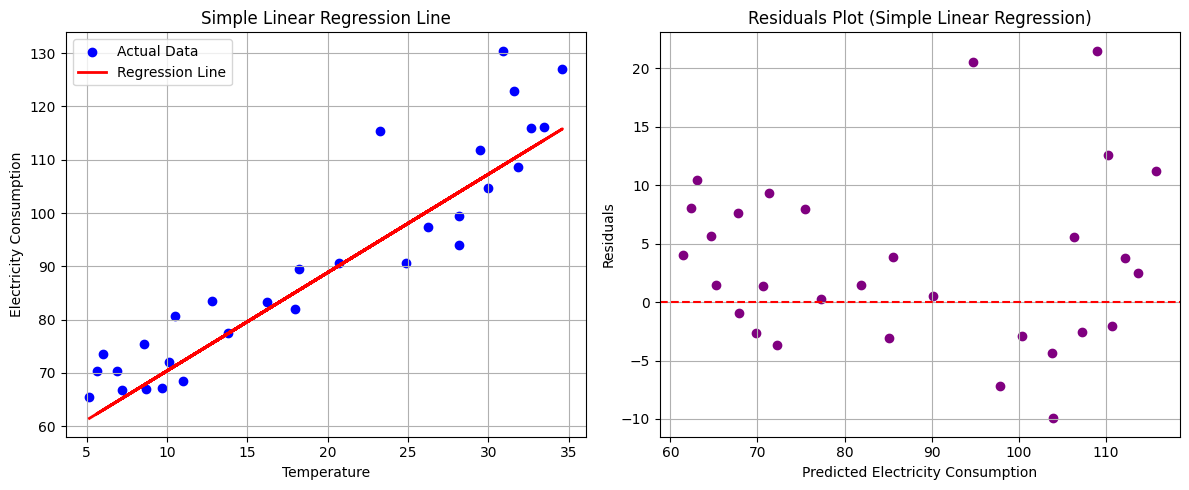

In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Regression Line
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Temperature')
plt.ylabel('Electricity Consumption')
plt.title('Simple Linear Regression Line')
plt.legend()
plt.grid(True)

# Plot 2: Residuals
residuals_simple = y_test_simple - y_pred_simple
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Electricity Consumption')
plt.ylabel('Residuals')
plt.title('Residuals Plot (Simple Linear Regression)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Add another input feature: 'Humidity' (e.g., inversely correlated with consumption sometimes, or just noise)
humidity = np.random.uniform(30, 90, num_samples)
data_multiple = pd.DataFrame({'Temperature': temperature, 'Humidity': humidity, 'Electricity_Consumption': electricity_consumption})

# Define features (X) and target (y) for multiple regression
X_multiple = data_multiple[['Temperature', 'Humidity']]
y_multiple = data_multiple['Electricity_Consumption']

# Divide the data into training and testing sets
X_train_multiple, X_test_multiple, y_train_multiple, y_test_multiple = train_test_split(
    X_multiple, y_multiple, test_size=0.3, random_state=42
)

# Train a multiple linear regression model
model_multiple = LinearRegression()
model_multiple.fit(X_train_multiple, y_train_multiple)

# Make predictions on the test set
y_pred_multiple = model_multiple.predict(X_test_multiple)

# Print the slope and intercept
print(f"Multiple Linear Regression Model:")
print(f"  Intercept: {model_multiple.intercept_:.2f}")
print(f"  Coefficients (Temperature, Humidity): {model_multiple.coef_}")

# Calculate MAE, MSE, RMSE, and R^2
mae_multiple = mean_absolute_error(y_test_multiple, y_pred_multiple)
mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

print(f"\nPerformance Metrics (Multiple Linear Regression):")
print(f"  MAE: {mae_multiple:.2f}")
print(f"  MSE: {mse_multiple:.2f}")
print(f"  RMSE: {rmse_multiple:.2f}")
print(f"  R^2: {r2_multiple:.2f}")

Multiple Linear Regression Model:
  Intercept: 49.04
  Coefficients (Temperature, Humidity): [1.81170769 0.05816318]

Performance Metrics (Multiple Linear Regression):
  MAE: 5.88
  MSE: 63.26
  RMSE: 7.95
  R^2: 0.84


In [ ]:
print("\n--- Performance Comparison ---")
print(f"Simple Linear Regression:")
print(f"  MAE: {mae_simple:.2f}, MSE: {mse_simple:.2f}, RMSE: {rmse_simple:.2f}, R^2: {r2_simple:.2f}")
print(f"Multiple Linear Regression:")
print(f"  MAE: {mae_multiple:.2f}, MSE: {mse_multiple:.2f}, RMSE: {rmse_multiple:.2f}, R^2: {r2_multiple:.2f}")

if r2_multiple > r2_simple:
    print("\nConclusion: Multiple Linear Regression performs slightly better (higher R^2).")
else:
    print("\nConclusion: Simple Linear Regression performs similarly or slightly better (higher R^2).")


--- Performance Comparison ---
Simple Linear Regression:
  MAE: 5.97, MSE: 63.09, RMSE: 7.94, R^2: 0.84
Multiple Linear Regression:
  MAE: 5.88, MSE: 63.26, RMSE: 7.95, R^2: 0.84

Conclusion: Simple Linear Regression performs similarly or slightly better (higher R^2).


In [ ]:
# Create a copy of the simple dataset
data_outlier = data_simple.copy()

# Add an outlier: high temperature, but very low consumption
outlier_temp = 40 # Outside normal range
outlier_consumption = 20 # Very low for this temperature

# Append the outlier to the dataset
data_outlier.loc[len(data_outlier)] = [outlier_temp, outlier_consumption]

display(data_outlier.tail())

# Define features (X) and target (y) for the outlier dataset
X_outlier = data_outlier[['Temperature']]
y_outlier = data_outlier['Electricity_Consumption']

# Divide the data into training and testing sets (with the outlier in training for impact)
X_train_outlier, X_test_outlier, y_train_outlier, y_test_outlier = train_test_split(
    X_outlier, y_outlier, test_size=0.3, random_state=42 # Using the same random state
)

# Train a new simple linear regression model with the outlier
model_outlier = LinearRegression()
model_outlier.fit(X_train_outlier, y_train_outlier)

# Make predictions on the test set
y_pred_outlier = model_outlier.predict(X_test_outlier)

# Print the slope and intercept for the model with outlier
print(f"\nSimple Linear Regression Model (with Outlier):")
print(f"  Intercept: {model_outlier.intercept_:.2f}")
print(f"  Slope (Coefficient for Temperature): {model_outlier.coef_[0]:.2f}")

# Calculate MAE, MSE, RMSE, and R^2 for the model with outlier
mae_outlier = mean_absolute_error(y_test_outlier, y_pred_outlier)
mse_outlier = mean_squared_error(y_test_outlier, y_pred_outlier)
rmse_outlier = np.sqrt(mse_outlier)
r2_outlier = r2_score(y_test_outlier, y_pred_outlier)

print(f"\nPerformance Metrics (Simple Linear Regression with Outlier):")
print(f"  MAE: {mae_outlier:.2f}")
print(f"  MSE: {mse_outlier:.2f}")
print(f"  RMSE: {rmse_outlier:.2f}")
print(f"  R^2: {r2_outlier:.2f}")

print("\n--- Comparison with Original Simple Linear Regression ---")
print(f"Original R^2: {r2_simple:.2f}")
print(f"R^2 with Outlier: {r2_outlier:.2f}")
print("Notice how the R^2 value might decrease significantly, indicating a poorer fit due to the outlier.")

,Temperature,Electricity_Consumption
96,20.681985,90.592953
97,17.826231,89.063981
98,5.762574,64.292056
99,8.236743,74.745318
100,40.000000,20.000000



Simple Linear Regression Model (with Outlier):
  Intercept: 58.34
  Slope (Coefficient for Temperature): 1.50

Performance Metrics (Simple Linear Regression with Outlier):
  MAE: 5.61
  MSE: 56.61
  RMSE: 7.52
  R^2: 0.81

--- Comparison with Original Simple Linear Regression ---
Original R^2: 0.84
R^2 with Outlier: 0.81
Notice how the R^2 value might decrease significantly, indicating a poorer fit due to the outlier.


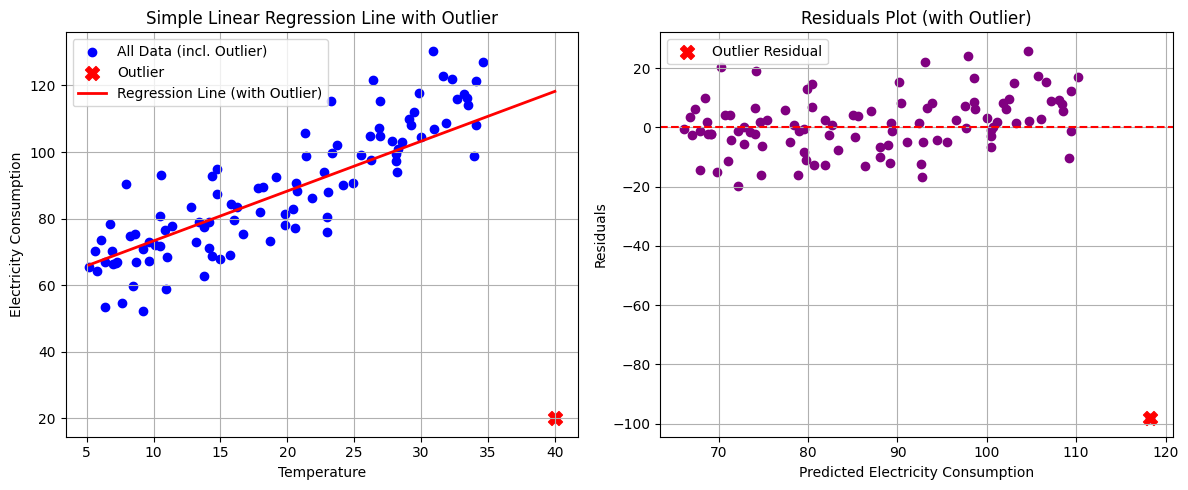

In [ ]:
plt.figure(figsize=(12, 5))

# Plot 1: Regression Line with Outlier
plt.subplot(1, 2, 1)
plt.scatter(X_outlier, y_outlier, color='blue', label='All Data (incl. Outlier)')
plt.scatter([outlier_temp], [outlier_consumption], color='red', marker='X', s=100, label='Outlier')
plt.plot(X_outlier.sort_values(by='Temperature'), model_outlier.predict(X_outlier.sort_values(by='Temperature')),
         color='red', linewidth=2, label='Regression Line (with Outlier)')
plt.xlabel('Temperature')
plt.ylabel('Electricity Consumption')
plt.title('Simple Linear Regression Line with Outlier')
plt.legend()
plt.grid(True)

# Plot 2: Residuals with Outlier
residuals_outlier = y_outlier - model_outlier.predict(X_outlier)
plt.subplot(1, 2, 2)
plt.scatter(model_outlier.predict(X_outlier), residuals_outlier, color='purple')
plt.scatter(model_outlier.predict(pd.DataFrame({'Temperature': [outlier_temp]})), residuals_outlier.iloc[-1:],
            color='red', marker='X', s=100, label='Outlier Residual')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Electricity Consumption')
plt.ylabel('Residuals')
plt.title('Residuals Plot (with Outlier)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()